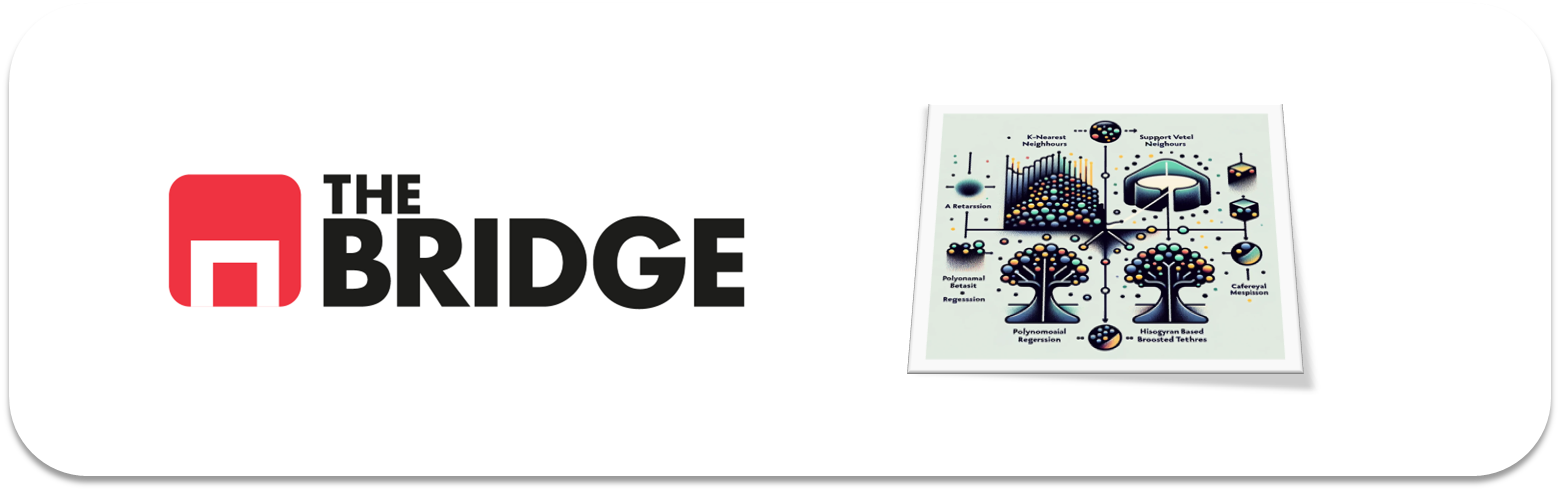

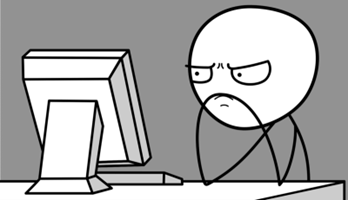

Para hacer un **repaso a los problemas de regresión con ML**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### INTRODUCCIóN: PROCESO DE ML

En los siguientes ejercicios vamos a seguir (de nuevo) los pasos básicos en la creación de un modelo de ML para resolver un problema de predicción a partir de un dataset que incluye el target, es decir, un aprendizaje supervisado.

En concreto, vamos a trabajar sobre un problema de clasificación a través de los siguientes pasos:

1. Entendimiento del problema (selección de la métrica más adecuada)  
2. Obtención de datos y primer contacto  
3. Train y Test  
4. MiniEDA: Análisis del target, análisis bivariante, entendimiento de las features, selección de las mismas (si es necesario)  
5. Preparación del dataset de Train: Conversión de categóricas, tratamiento de numéricas  
6. Selección e instanciación de modelos. Baseline.
7. Comparación de modelos (lo haremos por comparación con validación, puedes hacerlo por comparación de modelos de hiperparámetros optimizados, si así lo prefieres)  
8. Selección de modelo: Optimización de hiperparámetros (ten en cuenta la nota de 7)  
9. Evaluación contra test.  
10. Análisis de errores, posibles acciones futuras.  
11. EXTRA: Persistencia del modelo en disco.  

### El problema de Negocio

El ayuntamiento de Freehold, Nueva Jersey, está preocupado por los niveles de Ozono en situaciones de contaminación. Ha adquirido unos sensores muy potentes que permiten medir la composición de la calidad del aire casi en tiempo real, pero desgraciadamente la medida de Ozono se obtiene mucho más tarde (casi 12 horas después, este dato de las horas no es relevante para el problema). Las medidas son enviadas a una plataforma central donde se quiere incorporar un modelo que en función de esas medidas pueda predecir el nivel de $O_3$ (Ozono) en el aire y establecer alarmas y umbrales para avisar a la población o tomar medidas si es necesaria.

El concejal de urbanismo y tecnología, Bruce S., os contrata para que creéis ese modelo y para ello os suministra un dataset con medidas de la calidad de aire donde han incorporado el nivel de Ozono ("PT08.S5(O3)") posteriormente. Quieren un modelo que se equivoque en media en menos de 100 unidades por millón (la medida en la que tienen registrada la presencia de Ozono).

¡Manos a la obra!

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [52]:
import bootcampviztools as bt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import toolbox_ML as tool 

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, \
    mean_absolute_percentage_error, mean_squared_error, r2_score



### Ejercicio 1: Entendiendo el problema de "Negocio"

En función de la descripción del problema de "negocio" y sin mirar todavía los datos, ¿qué métricas crees más conveniente para medir el rendimiento del modelo a construir y, por tanto, para comparar posibles modelos entre sí?

In [2]:
from sklearn.metrics import get_scorer_names
sorted(get_scorer_names())

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'd2_brier_score',
 'd2_log_loss_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighte

Como es un problema de regresión utilizaré alguna de las siguientes, o todas si los datos lo permiten:  
En los modelos:     
'neg_mean_absolute_error',  
'neg_mean_absolute_percentage_error',  
'neg_median_absolute_error',  
'r2'.  
Para comparar las métricas: mean_absolute_error, mean_absolute_percentage_error,   median_absolute_error 


### Ejercicio 2: Obtención y primer "vistazo"

Carga el dataset, muestra sus primeras filas, su descripción general y determina el tipo de variables que vamos a manejar. Escoge el target y crea una variable `target` y asignalé el nombre de la columna correspondiente.

In [3]:
df = pd.read_csv("./data/air_contamination.csv")
df

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.600,48.875001,0.757754
1,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.300,47.700000,0.725487
2,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.900,53.975000,0.750239
3,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.000,60.000000,0.786713
4,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.150,59.575001,0.788794
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8986,3.1,1314.25,-200,13.529605,1101.25,471.7,538.50,189.8,1374.25,1728.50,21.850,29.250000,0.756824
8987,2.4,1162.50,-200,11.355157,1027.00,353.3,603.75,179.2,1263.50,1269.00,24.325,23.725000,0.711864
8988,2.4,1142.00,-200,12.374538,1062.50,293.0,603.25,174.7,1240.75,1092.00,26.900,18.350000,0.640649
8989,2.1,1002.50,-200,9.547187,960.50,234.5,701.50,155.7,1041.00,769.75,28.325,13.550000,0.513866


In [4]:
print(df.info())
print("\n")
print(tool.describe_df(df))
print("\n")
print(tool.tipifica_variables(df,umbral_categoria=10,umbral_continua=0.10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8991 entries, 0 to 8990
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         8991 non-null   float64
 1   PT08.S1(CO)    8991 non-null   float64
 2   NMHC(GT)       8991 non-null   int64  
 3   C6H6(GT)       8991 non-null   float64
 4   PT08.S2(NMHC)  8991 non-null   float64
 5   NOx(GT)        8991 non-null   float64
 6   PT08.S3(NOx)   8991 non-null   float64
 7   NO2(GT)        8991 non-null   float64
 8   PT08.S4(NO2)   8991 non-null   float64
 9   PT08.S5(O3)    8991 non-null   float64
 10  T              8991 non-null   float64
 11  RH             8991 non-null   float64
 12  AH             8991 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 913.3 KB
None


              data_type valores_nulos valores_unicos cardinalidad_ptg
CO(GT)         numerica           0.0             95             1.06
PT08.S1(CO)    numerica          

In [5]:
# Revisar valores faltantes
print(df.isna().sum())

CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [6]:
# Eliminar filas duplicadas si es necesario
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8991 entries, 0 to 8990
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         8991 non-null   float64
 1   PT08.S1(CO)    8991 non-null   float64
 2   NMHC(GT)       8991 non-null   int64  
 3   C6H6(GT)       8991 non-null   float64
 4   PT08.S2(NMHC)  8991 non-null   float64
 5   NOx(GT)        8991 non-null   float64
 6   PT08.S3(NOx)   8991 non-null   float64
 7   NO2(GT)        8991 non-null   float64
 8   PT08.S4(NO2)   8991 non-null   float64
 9   PT08.S5(O3)    8991 non-null   float64
 10  T              8991 non-null   float64
 11  RH             8991 non-null   float64
 12  AH             8991 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 913.3 KB


In [7]:
df.columns

Index(['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
       'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
       'T', 'RH', 'AH'],
      dtype='object')

In [8]:
target = ["PT08.S5(O3)"]
target_str = "PT08.S5(O3)"

### Ejercicio 3: Split

Haz el split en train y test.

In [9]:
train_set, test_set = train_test_split(df,test_size=0.2, random_state=42)
print(train_set.shape)
print(test_set.shape)

(7192, 13)
(1799, 13)


### Ejercicio 4: MiniEDA (I)

Analiza la distribución del target brevemente.

<Axes: ylabel='Count'>

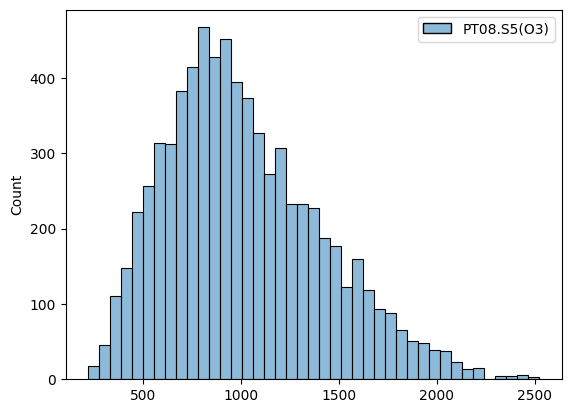

In [10]:
sns.histplot(train_set[target])

### Ejercicio 5: MiniEDA (II)

Analiza bivariantemente las variables contra el target, para las numéricas analiza la correlación numéricamente y gráficamente, para las categóricas analiza la distribución del target para cada valor de la categórica.

<Axes: >

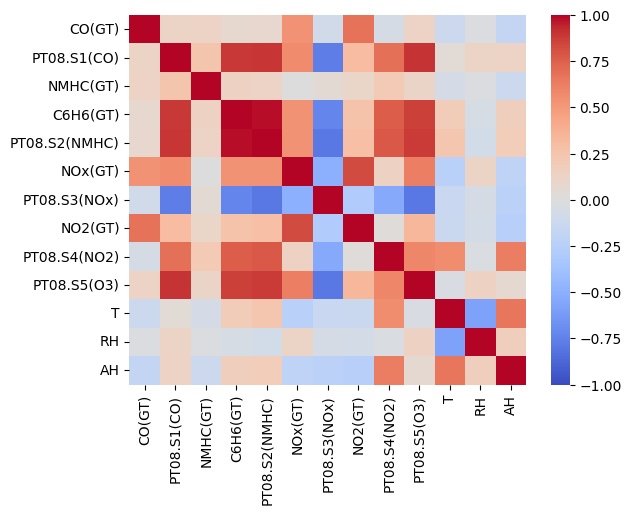

In [11]:
# Matriz de correlaciones
sns.heatmap(train_set.corr(numeric_only = True), annot=False, vmin = -1, vmax = 1, cmap='coolwarm')

In [12]:
print(train_set.corr())

                 CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  \
CO(GT)         1.000000     0.122506  0.129424  0.075437       0.083927   
PT08.S1(CO)    0.122506     1.000000  0.243351  0.884962       0.893618   
NMHC(GT)       0.129424     0.243351  1.000000  0.132976       0.129683   
C6H6(GT)       0.075437     0.884962  0.132976  1.000000       0.981825   
PT08.S2(NMHC)  0.083927     0.893618  0.129683  0.981825       1.000000   
NOx(GT)        0.537019     0.567169  0.000752  0.538124       0.535406   
PT08.S3(NOx)  -0.088243    -0.771052  0.053649 -0.733903      -0.795214   
NO2(GT)        0.676250     0.312481  0.105388  0.264477       0.284718   
PT08.S4(NO2)  -0.054931     0.679732  0.207487  0.764999       0.776315   
PT08.S5(O3)    0.128110     0.901005  0.110077  0.864269       0.879959   
T             -0.125947     0.044293 -0.068982  0.193377       0.236493   
RH            -0.019473     0.117609 -0.016271 -0.053293      -0.083230   
AH            -0.178433  

### Ejercicio 6: MiniEDA (III)

Crea una variable de tipo lista a la que asignes los valores de las columnas que creas conveniente emplear como features en función de lo visto en el miniEDA. Haz una lista de modelos/algoritmos que vas a emplear para hacer el modelo (solo los nombres). En función de la lista anterior, ¿tienes que tratar las variables, por qué?

In [13]:
features = ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
       'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'T', 'RH', 'AH']

¿"Regresión polinómica"? No según el gráfico de abajo que sea "Regresión Lineal", "RandomForestRegressor", "GradientBoostingRegressor", "XGBRegressor".
Si necesitamos tratar las features para la regresión lineal, escalar. El resto no lo necesita.

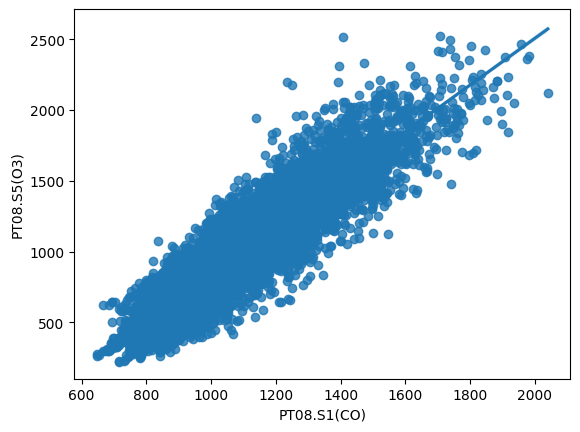

In [14]:
sns.regplot(data=train_set,  # regplot una nueva herramienta visual para tu caja de herramientas
            x= "PT08.S1(CO)",
            y= target_str);

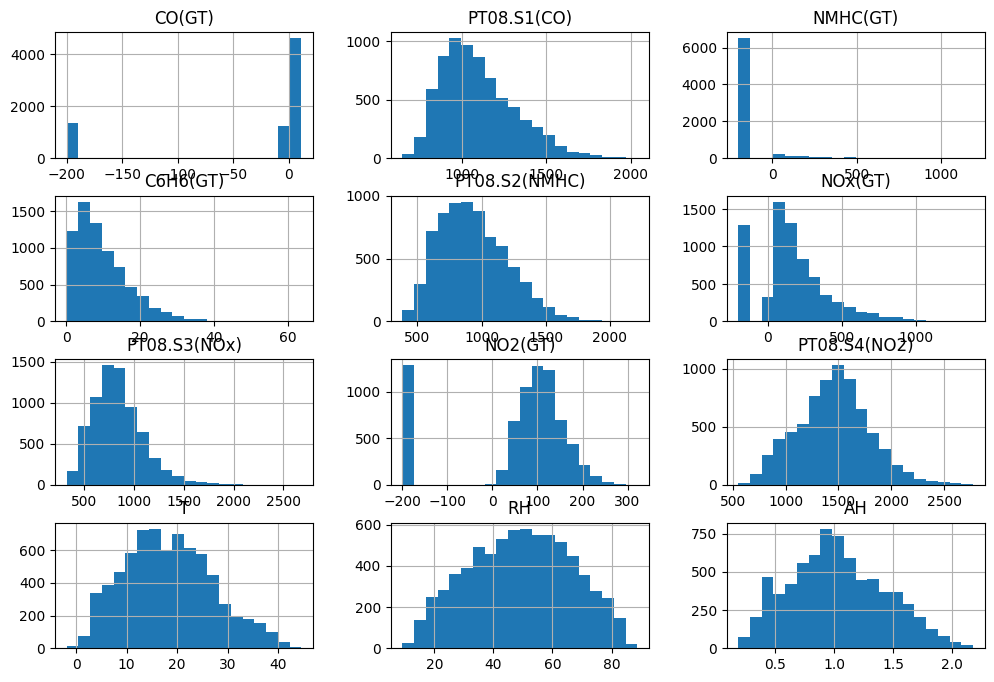

In [15]:
train_set[features].hist(figsize=(12,8), bins=20);

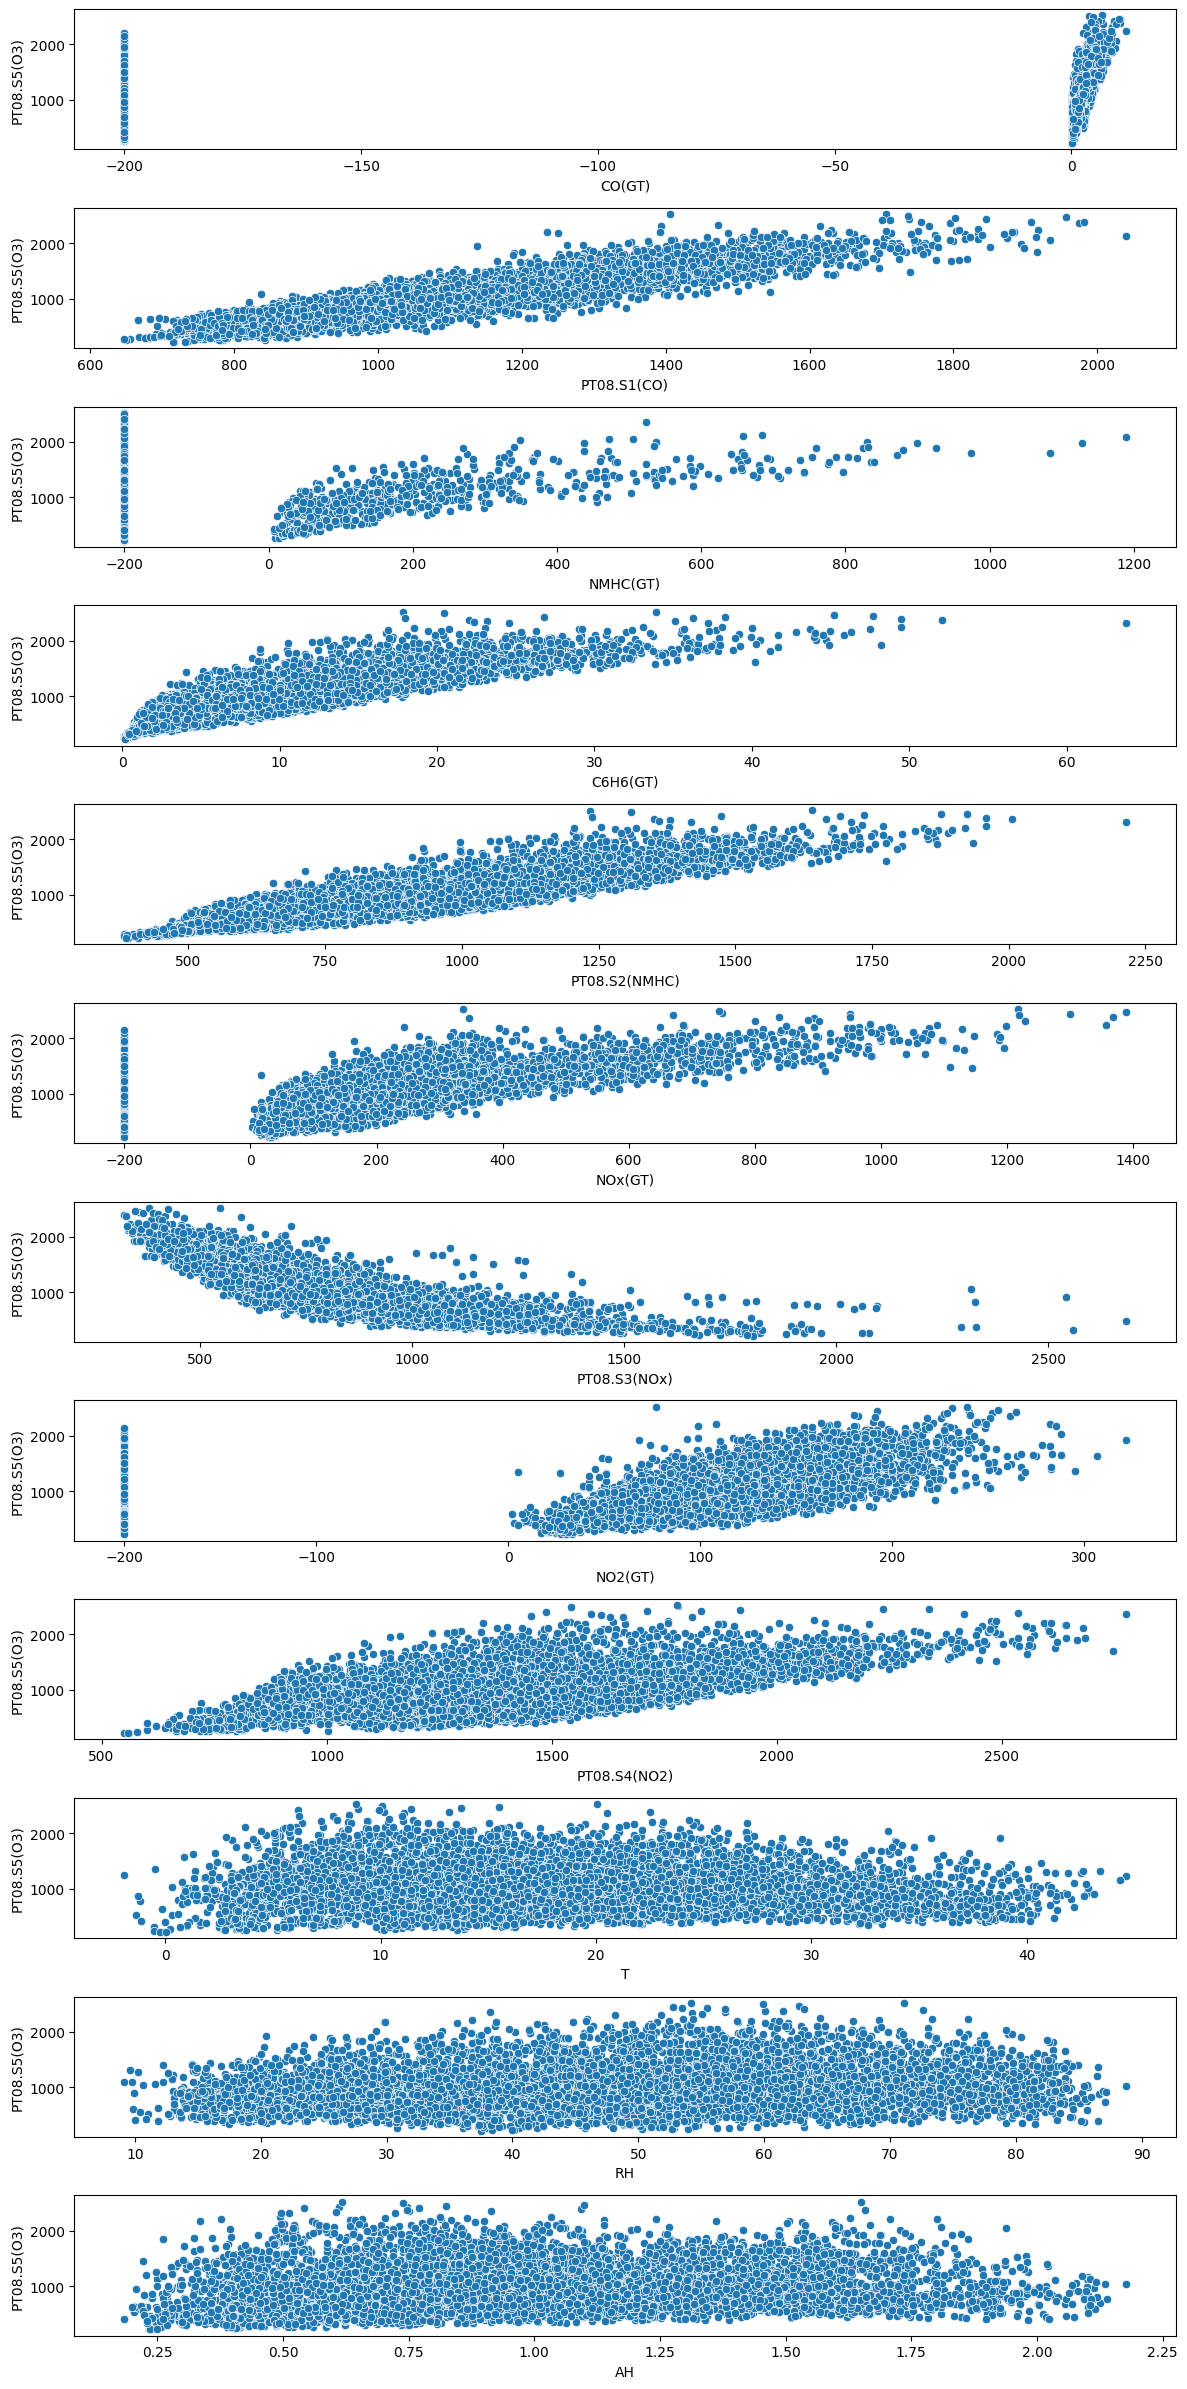

In [16]:
# Scatterplot para regresión
n = len(features)
fig, ax = plt.subplots(n,1, figsize=(12, n*2))

for i, feature in enumerate(features):
   sns.scatterplot(x= feature, y= target_str, data=train_set, ax=ax[i])
   
plt.tight_layout()
plt.show();

In [17]:
train_set[features].describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),T,RH,AH
count,7192.000000,7192.000000,7192.000000,7192.000000,7192.000000,7192.000000,7192.000000,7192.000000,7192.000000,7192.000000,7192.000000,7192.000000
mean,-35.402183,1096.742353,-160.296162,9.996265,935.740255,162.499027,838.543254,55.716838,1454.166956,18.347794,49.253558,1.027951
std,78.598763,217.187012,137.760344,7.413889,266.308898,251.498158,258.474047,126.820691,344.351668,8.827794,17.260384,0.403272
min,-200.000000,647.250000,-200.000000,0.149048,383.250000,-200.000000,322.000000,-200.000000,551.000000,-1.900000,9.175000,0.184679
25%,0.600000,933.250000,-200.000000,4.372234,730.937500,47.000000,661.250000,51.000000,1226.687500,11.825000,35.800001,0.738636
50%,1.400000,1059.250000,-200.000000,8.144817,905.125000,138.000000,807.875000,95.000000,1462.250000,17.775000,49.575000,0.997302
75%,2.500000,1225.750000,-200.000000,13.806061,1110.312500,280.000000,974.000000,131.000000,1668.250000,24.406250,62.574999,1.313524
max,11.500000,2039.750000,1189.000000,63.741476,2214.000000,1389.000000,2682.750000,321.600000,2775.000000,44.600000,88.725000,2.176616


Los -200 no son outliers, son valores faltantes.  
En el dataset Air Quality UCI, el valor -200 es el código que indica dato faltante (missing value), no un outlier real. Es una convención del dataset para señalar ausencia de medición.  
Some measurements may be recorded as -200, indicating missing or invalid data points.(Kaggle)

In [18]:
(train_set[features] == -200).sum()

# counting the no. of times -200 appears in the train_set
# train_set[features].isin([-200]).sum(axis=0)

CO(GT)           1335
PT08.S1(CO)         0
NMHC(GT)         6505
C6H6(GT)            0
PT08.S2(NMHC)       0
NOx(GT)          1283
PT08.S3(NOx)        0
NO2(GT)          1286
PT08.S4(NO2)        0
T                   0
RH                  0
AH                  0
dtype: int64

In [19]:
print((train_set[features] == -200).mean() * 100)

CO(GT)           18.562291
PT08.S1(CO)       0.000000
NMHC(GT)         90.447720
C6H6(GT)          0.000000
PT08.S2(NMHC)     0.000000
NOx(GT)          17.839266
PT08.S3(NOx)      0.000000
NO2(GT)          17.880979
PT08.S4(NO2)      0.000000
T                 0.000000
RH                0.000000
AH                0.000000
dtype: float64


In [20]:
features.remove('NMHC(GT)')
print(features, len(features))

['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'T', 'RH', 'AH'] 11


In [21]:
features_nulos = ["CO(GT)", "NOx(GT)", "NO2(GT)"]
features = [x for x in features if x not in features_nulos]

In [22]:
print(len(features), len(features_nulos))

8 3


In [23]:
train_set[features_nulos] = train_set[features_nulos].replace(-200, np.nan)

In [24]:
train_set[features].isin([-200]).sum(axis=0)

PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
PT08.S3(NOx)     0
PT08.S4(NO2)     0
T                0
RH               0
AH               0
dtype: int64

In [25]:
train_set[features_nulos].isna().sum(axis=0)

CO(GT)     1335
NOx(GT)    1283
NO2(GT)    1286
dtype: int64

In [26]:
train_set[features_nulos] = train_set[features_nulos].fillna(train_set[features_nulos].mean())

In [27]:
train_set[features].describe()

,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),T,RH,AH
count,7192.000000,7192.000000,7192.000000,7192.000000,7192.000000,7192.000000,7192.000000,7192.000000
mean,1096.742353,9.996265,935.740255,838.543254,1454.166956,18.347794,49.253558,1.027951
std,217.187012,7.413889,266.308898,258.474047,344.351668,8.827794,17.260384,0.403272
min,647.250000,0.149048,383.250000,322.000000,551.000000,-1.900000,9.175000,0.184679
25%,933.250000,4.372234,730.937500,661.250000,1226.687500,11.825000,35.800001,0.738636
50%,1059.250000,8.144817,905.125000,807.875000,1462.250000,17.775000,49.575000,0.997302
75%,1225.750000,13.806061,1110.312500,974.000000,1668.250000,24.406250,62.574999,1.313524
max,2039.750000,63.741476,2214.000000,2682.750000,2775.000000,44.600000,88.725000,2.176616


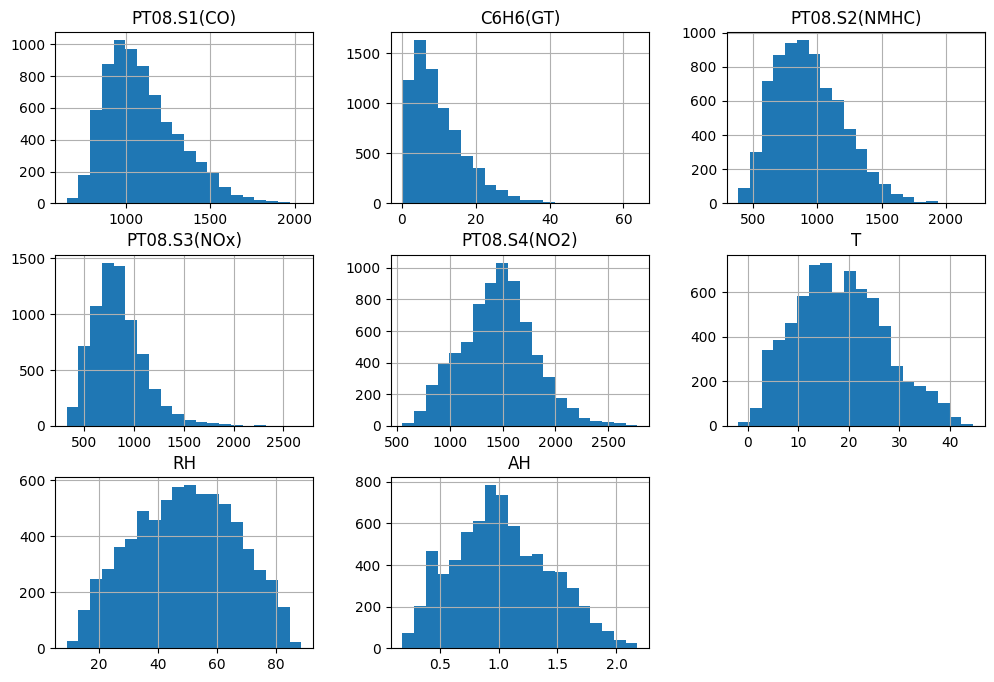

In [28]:
train_set[features].hist(figsize=(12,8), bins=20);

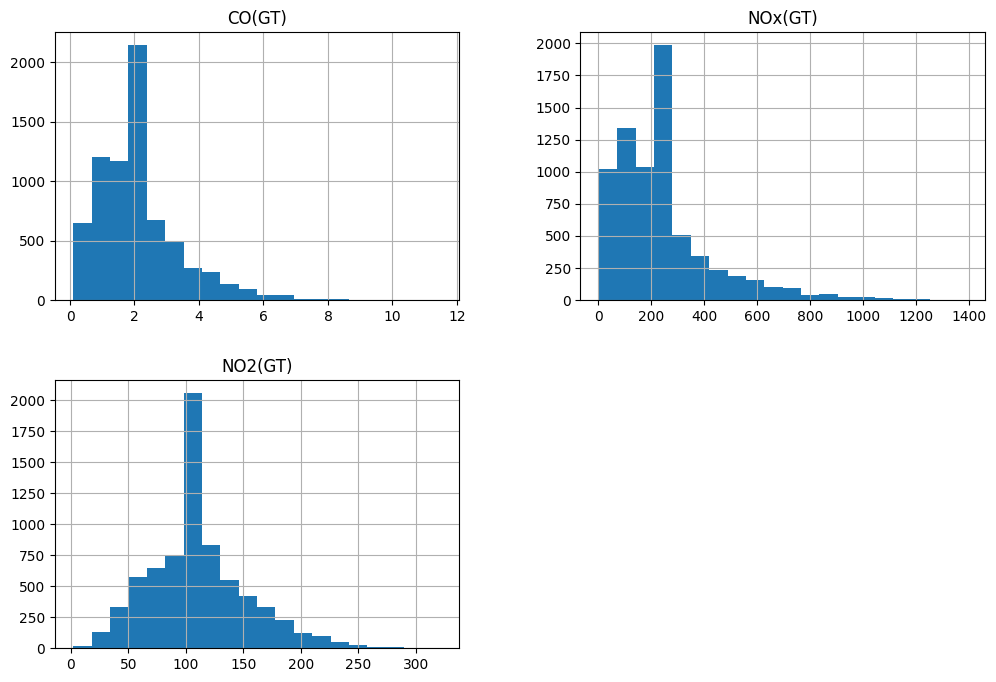

In [29]:
train_set[features_nulos].hist(figsize=(12,8), bins=20);

In [30]:
print(features)
print(features_nulos)

['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'T', 'RH', 'AH']
['CO(GT)', 'NOx(GT)', 'NO2(GT)']


In [31]:
test_set[features_nulos] = test_set[features_nulos].replace(-200, np.nan)
test_set[features_nulos] = test_set[features_nulos].fillna(train_set[features_nulos].mean())

In [32]:
features_log = ['C6H6(GT)', 'PT08.S3(NOx)','CO(GT)', 'NOx(GT)']
features = [x for x in features if x not in features_log]
features_nulos = [x for x in features_nulos if x not in features_log]
print(features)
print(features_nulos)
print(features_log)

['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S4(NO2)', 'T', 'RH', 'AH']
['NO2(GT)']
['C6H6(GT)', 'PT08.S3(NOx)', 'CO(GT)', 'NOx(GT)']


In [33]:
train_set[features_log]=np.log1p(train_set[features_log])
test_set[features_log] = np.log1p(test_set[features_log])

### Ejercicio 7: Tratamiento de features

Trata las features de manera que puedan ser empleadas por los modelos que escogite en el ejercicio anterior. Recuerda que este es un paso necesario porque los modelos no entienden de primeras de "letras" (salvo alguno que no es que entienda sino que hace sus transformaciones por dentro) y porque en determinados algoritmos es necesario que los rangos de las features estén escalados para que el algoritmo no se decante (érroneamente) por alguna feature sólo porque sus valores son mayores en rango que el de otras. NOTA: Recuerda que lo que le hagas al train, se lo tienes que hacer al test

In [34]:
features_final = features + features_nulos + features_log
features_final

['PT08.S1(CO)',
 'PT08.S2(NMHC)',
 'PT08.S4(NO2)',
 'T',
 'RH',
 'AH',
 'NO2(GT)',
 'C6H6(GT)',
 'PT08.S3(NOx)',
 'CO(GT)',
 'NOx(GT)']

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_set[features_final] = scaler.fit_transform(train_set[features_final])
test_set[features_final]= scaler.transform(test_set[features_final])

### Ejercicio 8: Creación de los dataset de train y test

Crea las parejas X,y de train y test.

In [37]:
X_train = train_set[features_final]
y_train = train_set[target].values.ravel()
X_test = test_set[features_final]
y_test= test_set[target].values.ravel()
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(7192, 11)
(7192,)
(1799, 11)
(1799,)


### Ejercicios 9:

Importa e instancia los modelos que hayas escogido en el ejercicio 6. En general, no hace falta que asignes ahora ningún hiperparámetro salvo en los basados en árboles en los que debes escoger un max_depth para evitar el sobreajuste inicial. 

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor

lin_reg = LinearRegression()
forest_reg = RandomForestRegressor(max_depth= 5, random_state=42)
gbr = GradientBoostingRegressor(max_depth=5)
xgbr = XGBRegressor(max_depth=5)

### Ejercicio 10: Comparativa de modelos

Haz la comparativa de modelos empleando cross_val_score (es decir la validación cruzada). Utiliza k = 5, y un scoring acorde a la métrica escogida en el ejercicio 1. Si no tienes clara la métrica entonces emplea "mean_absolute_error" (recuerda el funcionamiento del scoring en "sklearn", no te valdrá poner "mean_absolute_error"). Escoge el modelo ganador.

In [45]:
model_names = ["LinearRegression","RandomForestRegressor", "GradientBoostingRegressor", "XGBRegressor"]
model_set = [lin_reg, forest_reg, gbr, xgbr]
metricas_cv = {}
valores = []
for nombre,modelo in zip(model_names, model_set):
    print(type(modelo).__name__)
    metricas_cv[nombre] = cross_val_score(modelo, X_train, y_train, cv = 5, scoring = "neg_mean_absolute_error", verbose= 0)
    valores.append(np.mean(metricas_cv[nombre]))
ganador = list(metricas_cv.keys())[np.argmin(np.abs(valores))]

LinearRegression
RandomForestRegressor
GradientBoostingRegressor
XGBRegressor


In [46]:
for model_name, valores in metricas_cv.items():
    print(f"Model <{model_name}>, MAE: {np.abs(valores)}")
print(f"El ganador es {ganador}")

Model <LinearRegression>, MAE: [104.88071506 107.66062574 103.38238914 102.19110572 108.19029896]
Model <RandomForestRegressor>, MAE: [103.5868021  104.71073618 100.21913604 102.06520153 106.00256201]
Model <GradientBoostingRegressor>, MAE: [83.24510547 84.90929851 80.96598972 79.49611301 83.15279117]
Model <XGBRegressor>, MAE: [83.92683046 85.0026396  79.00321912 78.94227631 81.8783362 ]
El ganador es XGBRegressor


In [47]:
# neg_mean_squared_error
model_names = ["LinearRegression","RandomForestRegressor", "GradientBoostingRegressor", "XGBRegressor"]
model_set = [lin_reg, forest_reg, gbr, xgbr]
metricas_cv = {}
valores = []
for nombre,modelo in zip(model_names, model_set):
    print(type(modelo).__name__)
    metricas_cv[nombre] = cross_val_score(modelo, X_train, y_train, cv = 5, scoring = "neg_mean_squared_error", verbose= 0)
    valores.append(np.mean(metricas_cv[nombre]))
ganador = list(metricas_cv.keys())[np.argmin(np.abs(valores))]

LinearRegression
RandomForestRegressor
GradientBoostingRegressor
XGBRegressor


In [48]:
for model_name, valores in metricas_cv.items():
    print(f"Model <{model_name}>, MSE: {np.abs(valores)}")
print(f"El ganador es {ganador}")

Model <LinearRegression>, MSE: [17975.52082097 19782.01399772 17644.77911885 16747.96200987
 19686.91300757]
Model <RandomForestRegressor>, MSE: [17219.79586349 19132.4930799  16772.3692868  16791.25129288
 18881.38600366]
Model <GradientBoostingRegressor>, MSE: [12130.29056486 13452.57077047 11637.80580362 10739.16728857
 12399.65523881]
Model <XGBRegressor>, MSE: [12386.66843613 13221.5164336  11509.18470879 10803.26364751
 11800.28459282]
El ganador es XGBRegressor


### Ejercicio 11: Ajuste de hiperparámetros

Escoge un grid para ajustar los hiperparámetros de tu modelo. Crea un objeto GridSearch y "ajustalo" (emplea su método fit) para encontrar la mejor combinación de hiperparámetros empleando la métrica que decidimos en el ejercio 1. Si no lo tienes claro emplea "mean absolute error". 

In [49]:
from sklearn.model_selection import GridSearchCV
scorers =["neg_mean_absolute_error", "neg_mean_squared_error", "r2"]
xgbr = XGBRegressor(max_depth=5)
params_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100,200,500],
    "max_depth": [5,10,20],
    "subsample": [0.5, 0.75, 1] 
}

grid_xgbr = GridSearchCV(xgbr,
                       param_grid= params_grid,
                       cv =5, 
                       scoring= scorers,
                       refit= "r2",
                       return_train_score= True,
                       n_jobs= -1,
                       verbose=0)

grid_xgbr.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [5, 10, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.5, 0.75, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['neg_mean_absolute_error', 'neg_mean_squared_error', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more me

In [50]:
scorers =["neg_mean_absolute_error", "neg_mean_squared_error", "r2"]
gbr = GradientBoostingRegressor()
params_grid = {
    "learning_rate": [0.01, 0.1],
    "n_estimators": [100,500],
    "max_depth": [5,10],
    "subsample": [0.5, 1],
    "loss": ["absolute_error", "squared_error"],
    "min_samples_leaf": [10, 50] 
}

grid_gbr = GridSearchCV(gbr,
                       param_grid= params_grid,
                       cv =5, 
                       scoring= scorers,
                       refit= "r2",
                       return_train_score= True,
                       n_jobs= -1,
                       verbose=0)

grid_gbr.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1], 'loss': ['absolute_error', 'squared_error'], 'max_depth': [5, 10], 'min_samples_leaf': [10, 50], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['neg_mean_absolute_error', 'neg_mean_squared_error', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more me

### Ejercicio 12: Evaluación del modelo

Evalúa el modelo contra el dataset de test. Muestra el informe de clasificación y haz una valoración de si el hospital aceptaría el modelo o no.

In [51]:
print(grid_xgbr.best_estimator_)
print(grid_xgbr.best_score_)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)
0.9367096218214666


In [53]:
grid_xgbr.n_features_in_

11

In [54]:
y_pred_grid_xgbr = grid_xgbr.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred_grid_xgbr))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_grid_xgbr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_grid_xgbr)))
print("R2:", (r2_score(y_test, y_pred_grid_xgbr)))

MAE: 71.0725622454551
MAPE: 0.07398892578011103
RMSE: 100.34848366060484
R2: 0.9371648430168309


In [63]:
print(df[target_str].describe())

count    8991.000000
mean     1022.780725
std       398.480897
min       221.000000
25%       731.375000
50%       963.250000
75%      1273.375000
max      2522.750000
Name: PT08.S5(O3), dtype: float64


### Ejercicio 13: Análisis de errores

Comparar los valores predichos contra los reales mediante una gráfica (puedes emplear la función que empleamos en el workout de la unidad anterior). Haz un pequeño análisis.

In [55]:

def plot_predictions_vs_actual(y_real, y_pred):
    """
    Función para graficar los valores reales vs. los valores predichos en una regresión.

    Args:
    y_real (array-like): Valores reales de la variable objetivo.
    y_pred (array-like): Valores predichos de la variable objetivo.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, y_real, alpha=0.5)
    plt.xlabel("Valores Predichos")
    plt.ylabel("Valores Reales")

    # Línea y=x
    max_value = max(max(y_real), max(y_pred))
    min_value = min(min(y_real), min(y_pred))
    plt.plot([min_value, max_value], [min_value, max_value], 'r')

    plt.title("Comparación de Valores Reales vs. Predichos")
    plt.show()

# Ejemplo de uso
# plot_predictions_vs_actual(y_real, y_pred)

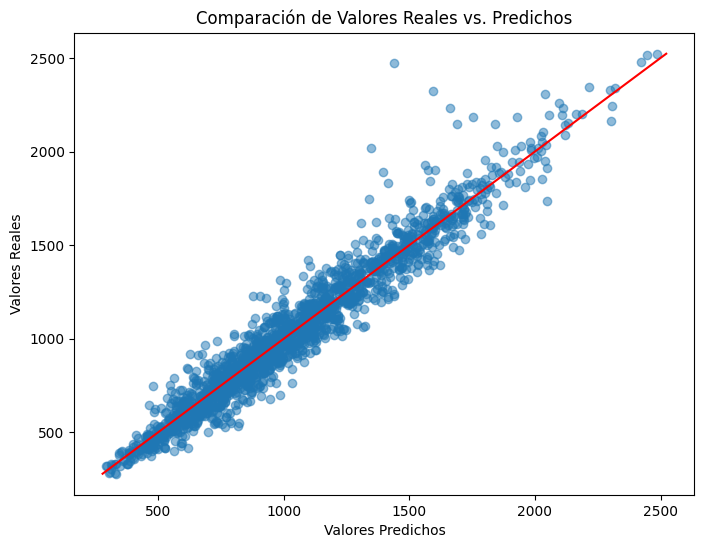

In [56]:
plot_predictions_vs_actual(y_test, y_pred_grid_xgbr)

In [57]:
print(grid_gbr.best_estimator_)
print(grid_gbr.best_score_)
print(grid_gbr.feature_names_in_)
y_pred_grid_gbr = grid_gbr.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred_grid_gbr))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_grid_gbr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_grid_gbr)))
print("R2:", (r2_score(y_test, y_pred_grid_gbr)))

GradientBoostingRegressor(learning_rate=0.01, max_depth=10, min_samples_leaf=10,
                          n_estimators=500, subsample=0.5)
0.9345759396593719
['PT08.S1(CO)' 'PT08.S2(NMHC)' 'PT08.S4(NO2)' 'T' 'RH' 'AH' 'NO2(GT)'
 'C6H6(GT)' 'PT08.S3(NOx)' 'CO(GT)' 'NOx(GT)']
MAE: 73.59172582628358
MAPE: 0.07732317241424957
RMSE: 103.19796062121381
R2: 0.9335456666633809


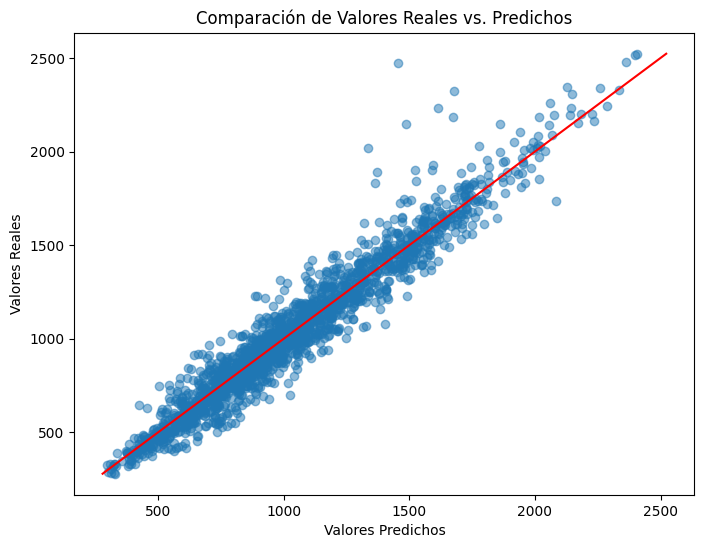

In [58]:
plot_predictions_vs_actual(y_test, y_pred_grid_gbr)

El mejor sigue siendo: XGBRegressor.

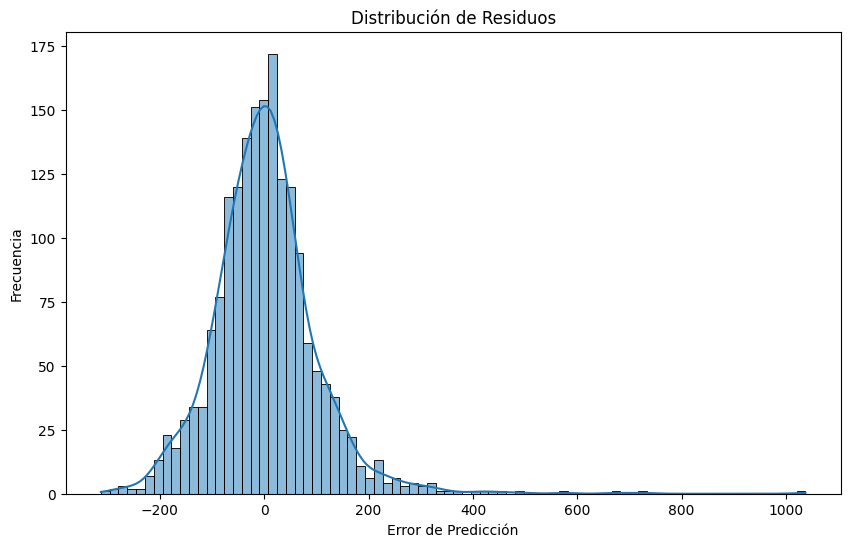

In [59]:
# Calcular residuos
residuos = y_test - y_pred_grid_xgbr

# Visualización de residuos
plt.figure(figsize=(10, 6))
sns.histplot(residuos, kde=True)
plt.title('Distribución de Residuos')
plt.xlabel('Error de Predicción')
plt.ylabel('Frecuencia')
plt.show()

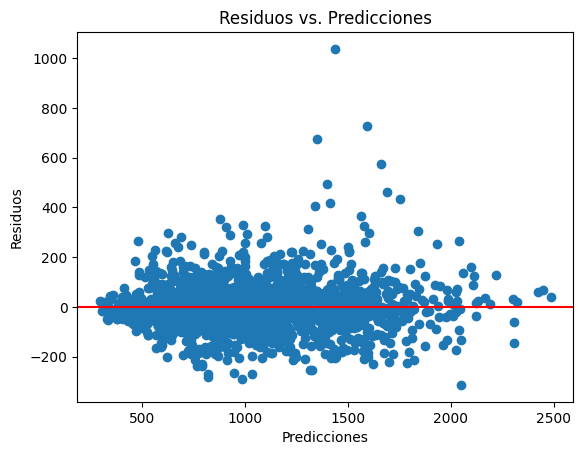

In [60]:
# Gráfica de dispersión de residuos
plt.scatter(y_pred_grid_xgbr, residuos)
plt.title('Residuos vs. Predicciones')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.axhline(y=0, color='r', linestyle='-')
plt.show()

### EXTRA: 

Busca en Internet o pregúntale a tu AI preferida, cómo se graba un modelo en disco y gúardalo en "./models/o3_pred" con la extesión apropiada.

In [61]:
import joblib
joblib.dump({
    'model': grid_xgbr,
    'scaler': scaler,
    'features': features_final,
    'preprocessing': {'log1p': True},
    'best_params': grid_xgbr.best_params_
}, './models/o3_pred.pkl.gz', compress=3)

['./models/o3_pred.pkl.gz']

NOTA: Transformación logarítmica del target.